# MIDTERM PROJECT
# IMAGE CLASSIFICATION USING HOG + SVM
# EMNIST LETTERS DATASET

In [1]:
# Import libraries used across the notebook
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# scikit-learn
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# scikit-image HOG (may need installation)
# scikit-image HOG
from skimage.feature import hog as skimage_hog

print('imports ok')

imports ok


# LOAD DATASET

In [2]:
dataset_path = "emnist-letters-train.csv"
data = pd.read_csv(dataset_path, header=None)

# SPLIT LABEL DAN IMAGE
labels = data.iloc[:, 0].values
images = data.iloc[:, 1:].values

print("Jumlah Total Dataset :", len(labels))
print("Ukuran Image Dataset :", images.shape)

# MEMBUAT DATASET BALANCE
# 26 KELAS
# 100 SAMPLE PER KELAS
# TOTAL = 2600 SAMPLE
selected_images = []
selected_labels = []

for class_id in range(1, 27):

    # Ambil index berdasarkan class
    idx = np.where(labels == class_id)[0]

    # Shuffle index
    np.random.shuffle(idx)

    # Ambil 100 sample
    idx = idx[:100]

    # Simpan image dan label
    selected_images.append(images[idx])
    selected_labels.append(labels[idx])
# Gabungkan seluruh data
selected_images = np.vstack(selected_images)
selected_labels = np.hstack(selected_labels)

print("Jumlah Dataset Balance :", len(selected_labels))

Jumlah Total Dataset : 88800
Ukuran Image Dataset : (88800, 784)
Jumlah Dataset Balance : 2600


# SHUFFLE DATASET

In [3]:
shuffle_idx = np.random.permutation(len(selected_labels))

selected_images = selected_images[shuffle_idx]
selected_labels = selected_labels[shuffle_idx]

print("Dataset berhasil di-shuffle")

Dataset berhasil di-shuffle


# VISUALISASI DATASET

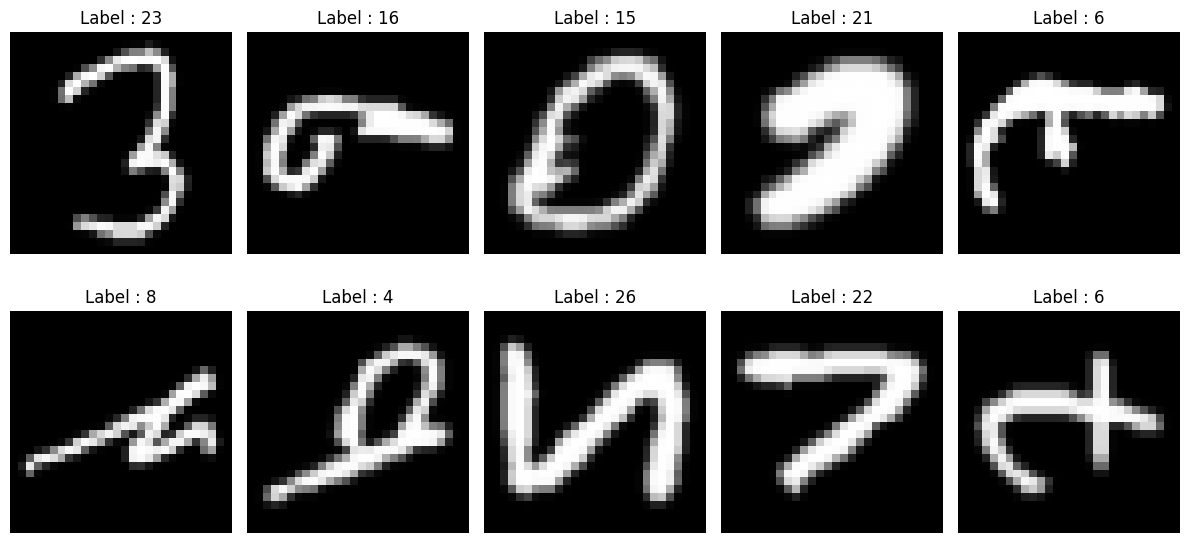

In [4]:
plt.figure(figsize=(12, 6))

for i in range(10):

    img = selected_images[i].reshape(28, 28)

    plt.subplot(2, 5, i + 1)

    plt.imshow(img, cmap='gray')

    plt.title(f"Label : {selected_labels[i]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

# HOG FEATURE EXTRACTION

In [5]:
hog_features = []

for img in selected_images:

    # Reshape menjadi 28x28
    img = img.reshape(28, 28)

    # HOG Extraction
    features = skimage_hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    hog_features.append(features)

# Konversi ke numpy array
hog_features = np.array(hog_features)

print("Ukuran HOG Feature :", hog_features.shape)

Ukuran HOG Feature : (2600, 1296)


# GRID SEARCH SVM

Iteration : 100
Iteration : 200
Iteration : 300
Iteration : 400
Iteration : 500
Iteration : 600
Iteration : 700
Iteration : 800
Iteration : 900
Iteration : 1000
Iteration : 1100
Iteration : 1200
Iteration : 1300
Iteration : 1400
Iteration : 1500
Iteration : 1600
Iteration : 1700
Iteration : 1800
Iteration : 1900
Iteration : 2000
Iteration : 2100
Iteration : 2200
Iteration : 2300
Iteration : 2400
Iteration : 2500
Iteration : 2600

LOOCV PERFORMANCE
Accuracy  : 0.8365384615384616
Precision : 0.8376474265610815
Recall    : 0.8365384615384616
F1-Score  : 0.8365679582693606

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       0.75      0.80      0.77       100
           2       0.87      0.89      0.88       100
           3       0.85      0.88      0.87       100
           4       0.85      0.89      0.87       100
           5       0.87      0.89      0.88       100
           6       0.80      0.84      0.82       100
           7       0.7

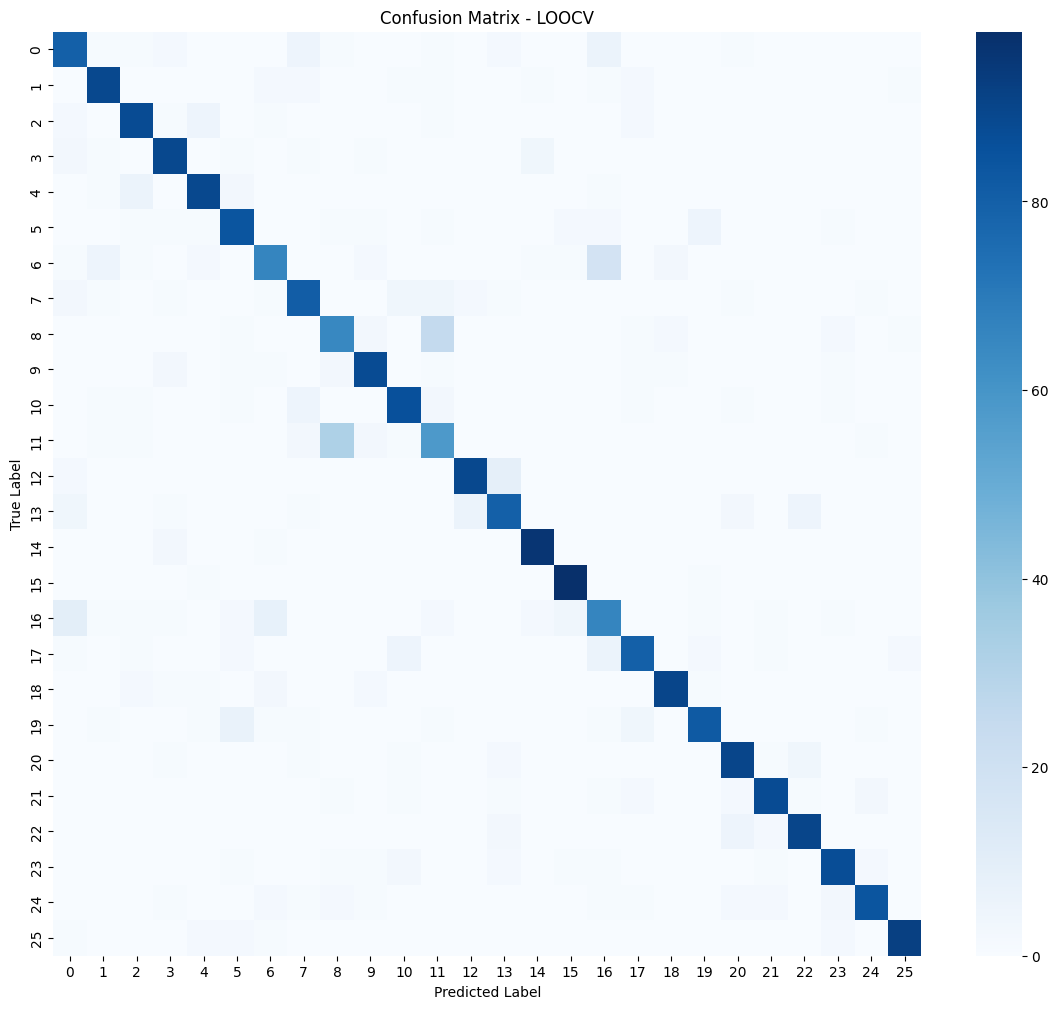

In [ ]:

# LOOCV (LEAVE ONE OUT CROSS VALIDATION)

from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

y_true = []
y_pred = []

iteration = 1

for train_index, test_index in loo.split(hog_features):

    # Split data
    X_train = hog_features[train_index]
    X_test = hog_features[test_index]

    y_train = selected_labels[train_index]
    y_test = selected_labels[test_index]

   
    # SVM MODEL
   

    model = SVC(
        kernel='rbf',
        C=10,
        gamma=0.01
    )

    # Training
    model.fit(X_train, y_train)

    # Predict
    prediction = model.predict(X_test)

    # Simpan hasil
    y_true.append(y_test[0])
    y_pred.append(prediction[0])

    # Progress
    if iteration % 100 == 0:
        print(f"Iteration : {iteration}")

    iteration += 1


# EVALUATION

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_true,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)

# =========================================================
# RESULT
# =========================================================

print("\n===================================")
print("LOOCV PERFORMANCE")
print("===================================")

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(classification_report(y_true, y_pred))



# EVALUASI TRAINING

In [ ]:


accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_true,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)


# RESULT

print("LOOCV PERFORMANCE")

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

LOOCV PERFORMANCE
Accuracy  : 0.8365384615384616
Precision : 0.8376474265610815
Recall    : 0.8365384615384616
F1-Score  : 0.8365679582693606


# EVALUASI TESTING

In [ ]:

# EVALUATION LOOCV


accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='macro'
)

recall = recall_score(
    y_true,
    y_pred,
    average='macro'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='macro'
)


# HASIL EVALUASI



print("LOOCV PERFORMANCE")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)


LOOCV PERFORMANCE
Accuracy  : 0.8365384615384616
Precision : 0.8376474265610815
Recall    : 0.8365384615384616
F1-Score  : 0.8365679582693606
              precision    recall  f1-score   support

           1       0.75      0.80      0.77       100
           2       0.87      0.89      0.88       100
           3       0.85      0.88      0.87       100
           4       0.85      0.89      0.87       100
           5       0.87      0.89      0.88       100
           6       0.80      0.84      0.82       100
           7       0.76      0.66      0.71       100
           8       0.80      0.81      0.81       100
           9       0.61      0.65      0.63       100
          10       0.86      0.88      0.87       100
          11       0.84      0.86      0.85       100
          12       0.59      0.58      0.59       100
          13       0.92      0.89      0.90       100
          14       0.80      0.80      0.80       100
          15       0.92      0.96      0.94   

# CLASSIFICATION REPORT

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           1       0.75      0.80      0.77       100
           2       0.87      0.89      0.88       100
           3       0.85      0.88      0.87       100
           4       0.85      0.89      0.87       100
           5       0.87      0.89      0.88       100
           6       0.80      0.84      0.82       100
           7       0.76      0.66      0.71       100
           8       0.80      0.81      0.81       100
           9       0.61      0.65      0.63       100
          10       0.86      0.88      0.87       100
          11       0.84      0.86      0.85       100
          12       0.59      0.58      0.59       100
          13       0.92      0.89      0.90       100
          14       0.80      0.80      0.80       100
          15       0.92      0.96      0.94       100
          16       0.92      0.98      0.95       100
          17       0.63      0.66      0.65       100
     

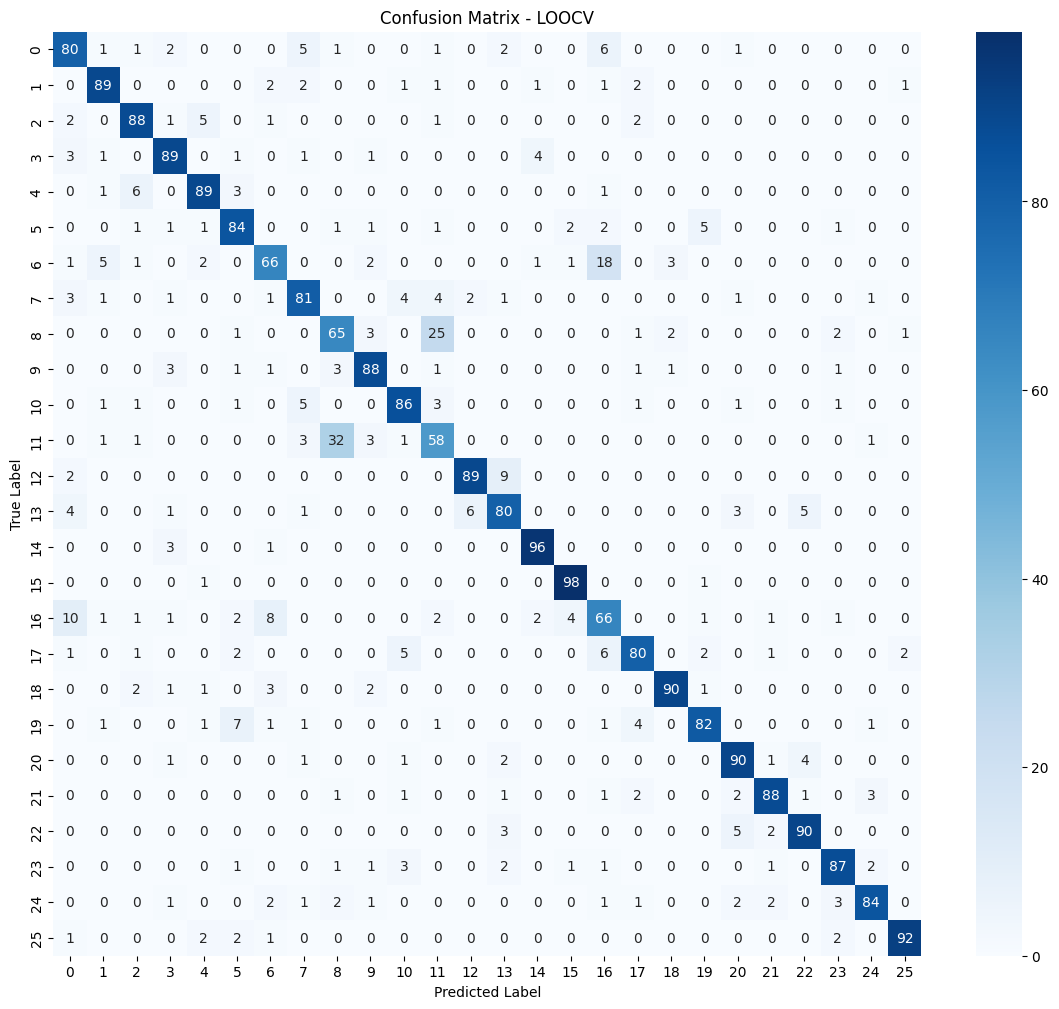

In [28]:

print("CLASSIFICATION REPORT")


print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - LOOCV")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()








